In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import geopandas as gpd
from shapely.geometry import Point
from sklearn.cluster import DBSCAN
import geopandas as gpd
pd.set_option('display.max_columns', 500)
import contextily as ctx

In [23]:
df = pd.read_csv('C:\\Studia\\Master\\master_thesis\\data\\data1.csv', sep = ';')

In [24]:
powiaty = gpd.read_file('C:\\Studia\\Master\\master_thesis\\data\\powiaty.shp')

In [25]:
dzielnice = gpd.read_file('C:\\Studia\\Master\\master_thesis\\data\\dzielnice_Warszawy.shp')

In [26]:
geometry = [Point(lon, lat) for lon, lat in zip(df['lon'], df['lat'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

In [27]:
powiaty = powiaty.to_crs(gdf.crs)
dzielnice = dzielnice.to_crs(gdf.crs)

In [28]:
# ax = powiaty.plot(figsize=(30, 30), color='none', edgecolor='black')

# gdf.plot(ax=ax, color='red', markersize=0.1)
# # ctx.add_basemap(ax, crs=gdf.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

# plt.show() 

In [29]:
spatial_join_powiaty = gpd.sjoin(powiaty, gdf, how='inner', op='contains')

C:\Users\Filip\AppData\Roaming\Python\Python312\site-packages\IPython\core\interactiveshell.py:3517: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


In [31]:
powiaty_maz = spatial_join_powiaty[['JPT_NAZWA_', 'geometry']]


In [32]:
powiaty_maz

,JPT_NAZWA_,geometry
2,powiat ostrołęcki,"POLYGON ((21.20011 53.39916, 21.20178 53.40052..."
2,powiat ostrołęcki,"POLYGON ((21.20011 53.39916, 21.20178 53.40052..."
2,powiat ostrołęcki,"POLYGON ((21.20011 53.39916, 21.20178 53.40052..."
2,powiat ostrołęcki,"POLYGON ((21.20011 53.39916, 21.20178 53.40052..."
2,powiat ostrołęcki,"POLYGON ((21.20011 53.39916, 21.20178 53.40052..."
...,...,...
368,powiat Płock,"POLYGON ((19.69555 52.47374, 19.69474 52.47403..."
368,powiat Płock,"POLYGON ((19.69555 52.47374, 19.69474 52.47403..."
368,powiat Płock,"POLYGON ((19.69555 52.47374, 19.69474 52.47403..."
368,powiat Płock,"POLYGON ((19.69555 52.47374, 19.69474 52.47403..."


In [33]:
powiaty_maz = powiaty_maz.drop_duplicates(subset='JPT_NAZWA_')

<Axes: >

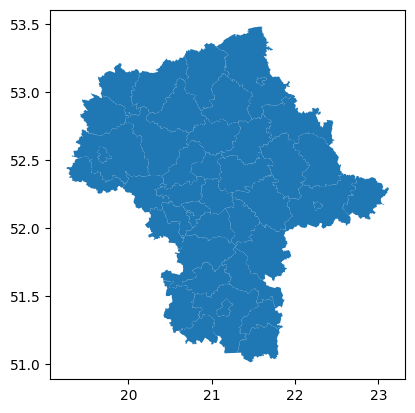

In [34]:
powiaty_maz.plot()

In [35]:
warsaw = gpd.sjoin(gdf, dzielnice,  how='inner', op='within')

C:\Users\Filip\AppData\Roaming\Python\Python312\site-packages\IPython\core\interactiveshell.py:3517: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


In [36]:
# ax = dzielnice.plot(figsize=(30, 30), color='none', edgecolor='black')

# warsaw.plot(ax=ax, column='if_hightech', markersize=3, legend=True, cmap='coolwarm')
# ctx.add_basemap(ax, crs=warsaw.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik, zoom=12)


# plt.show()

In [37]:
df[['SEK_PKD7', 'if_hightech']].query('if_hightech == 1').groupby('SEK_PKD7').count().sort_values(by = 'if_hightech', ascending = False)

,if_hightech
SEK_PKD7,
J,33366
C,8020
M,955


In [38]:
sek_fin_mask = df['SEK_PKD7'] == 'H'
df['if_fin'] = np.where(sek_fin_mask, 1, 0)

In [39]:
# df[['SEK_PKD7', 'if_hightech', 'PKD7']].query('if_hightech == 1 and SEK_PKD7 == C')
# df[(df['if_hightech'] == 1) & (df['SEK_PKD7'] == 'C')][['POWIAT', 'PKD7']].groupby(['POWIAT']).count()

In [41]:
# df[(df['if_fin'] == 1)][['if_fin', 'PKD7']].groupby(['PKD7']).count().apply(lambda x: x.sort_values(ascending=False))


In [42]:
kod_tech = pd.read_csv("C:\\Studia\\Master\\master_thesis\\data\\lista high tech.csv", sep = ";")

In [43]:
pop_point = pd.read_csv("C:\\Studia\\Master\\master_thesis\\data\\points_popul_maz.csv", sep = ",")

In [44]:
kod_tech_mapping = kod_tech.set_index('kod')['tech']

df['techSPEC'] = df['PKD7'].map(kod_tech_mapping)

df_copy = df.copy()

df_copy['techSPEC'] = df_copy['techSPEC'].fillna('other')

df_copy['techSPEC'].value_counts()

techSPEC
other                         941378
high-tech know-intens serv     34321
medium-high-tech                5847
high-tech                       2173
Name: count, dtype: int64

In [48]:
gdf_ht = gdf[gdf['if_hightech'] == 1]

In [52]:
import pickle

with open('gdf_ht.pickle', 'wb') as file:
    pickle.dump(gdf_ht, file)

In [61]:
import pickle

with open('gdf.pickle', 'wb') as file:
    pickle.dump(gdf, file)

In [64]:
with open('warsaw.pickle', 'wb') as file:
    pickle.dump(warsaw, file)

<>:1: SyntaxWarning: invalid escape sequence '\w'
<>:1: SyntaxWarning: invalid escape sequence '\w'
C:\Users\Filip\AppData\Local\Temp\ipykernel_21124\2168773605.py:1: SyntaxWarning: invalid escape sequence '\w'
  with open('data\warsaw.pickle', 'wb') as file:
C:\Users\Filip\AppData\Local\Temp\ipykernel_21124\2168773605.py:1: SyntaxWarning: invalid escape sequence '\w'
  with open('data\warsaw.pickle', 'wb') as file:


FileNotFoundError: [Errno 2] No such file or directory: 'data\\warsaw.pickle'

In [59]:
with open('dzielnice.pickle', 'wb') as file:
    pickle.dump(dzielnice, file)

In [54]:
with open('powiaty_maz.pickle', 'wb') as file:
    pickle.dump(powiaty_maz, file)

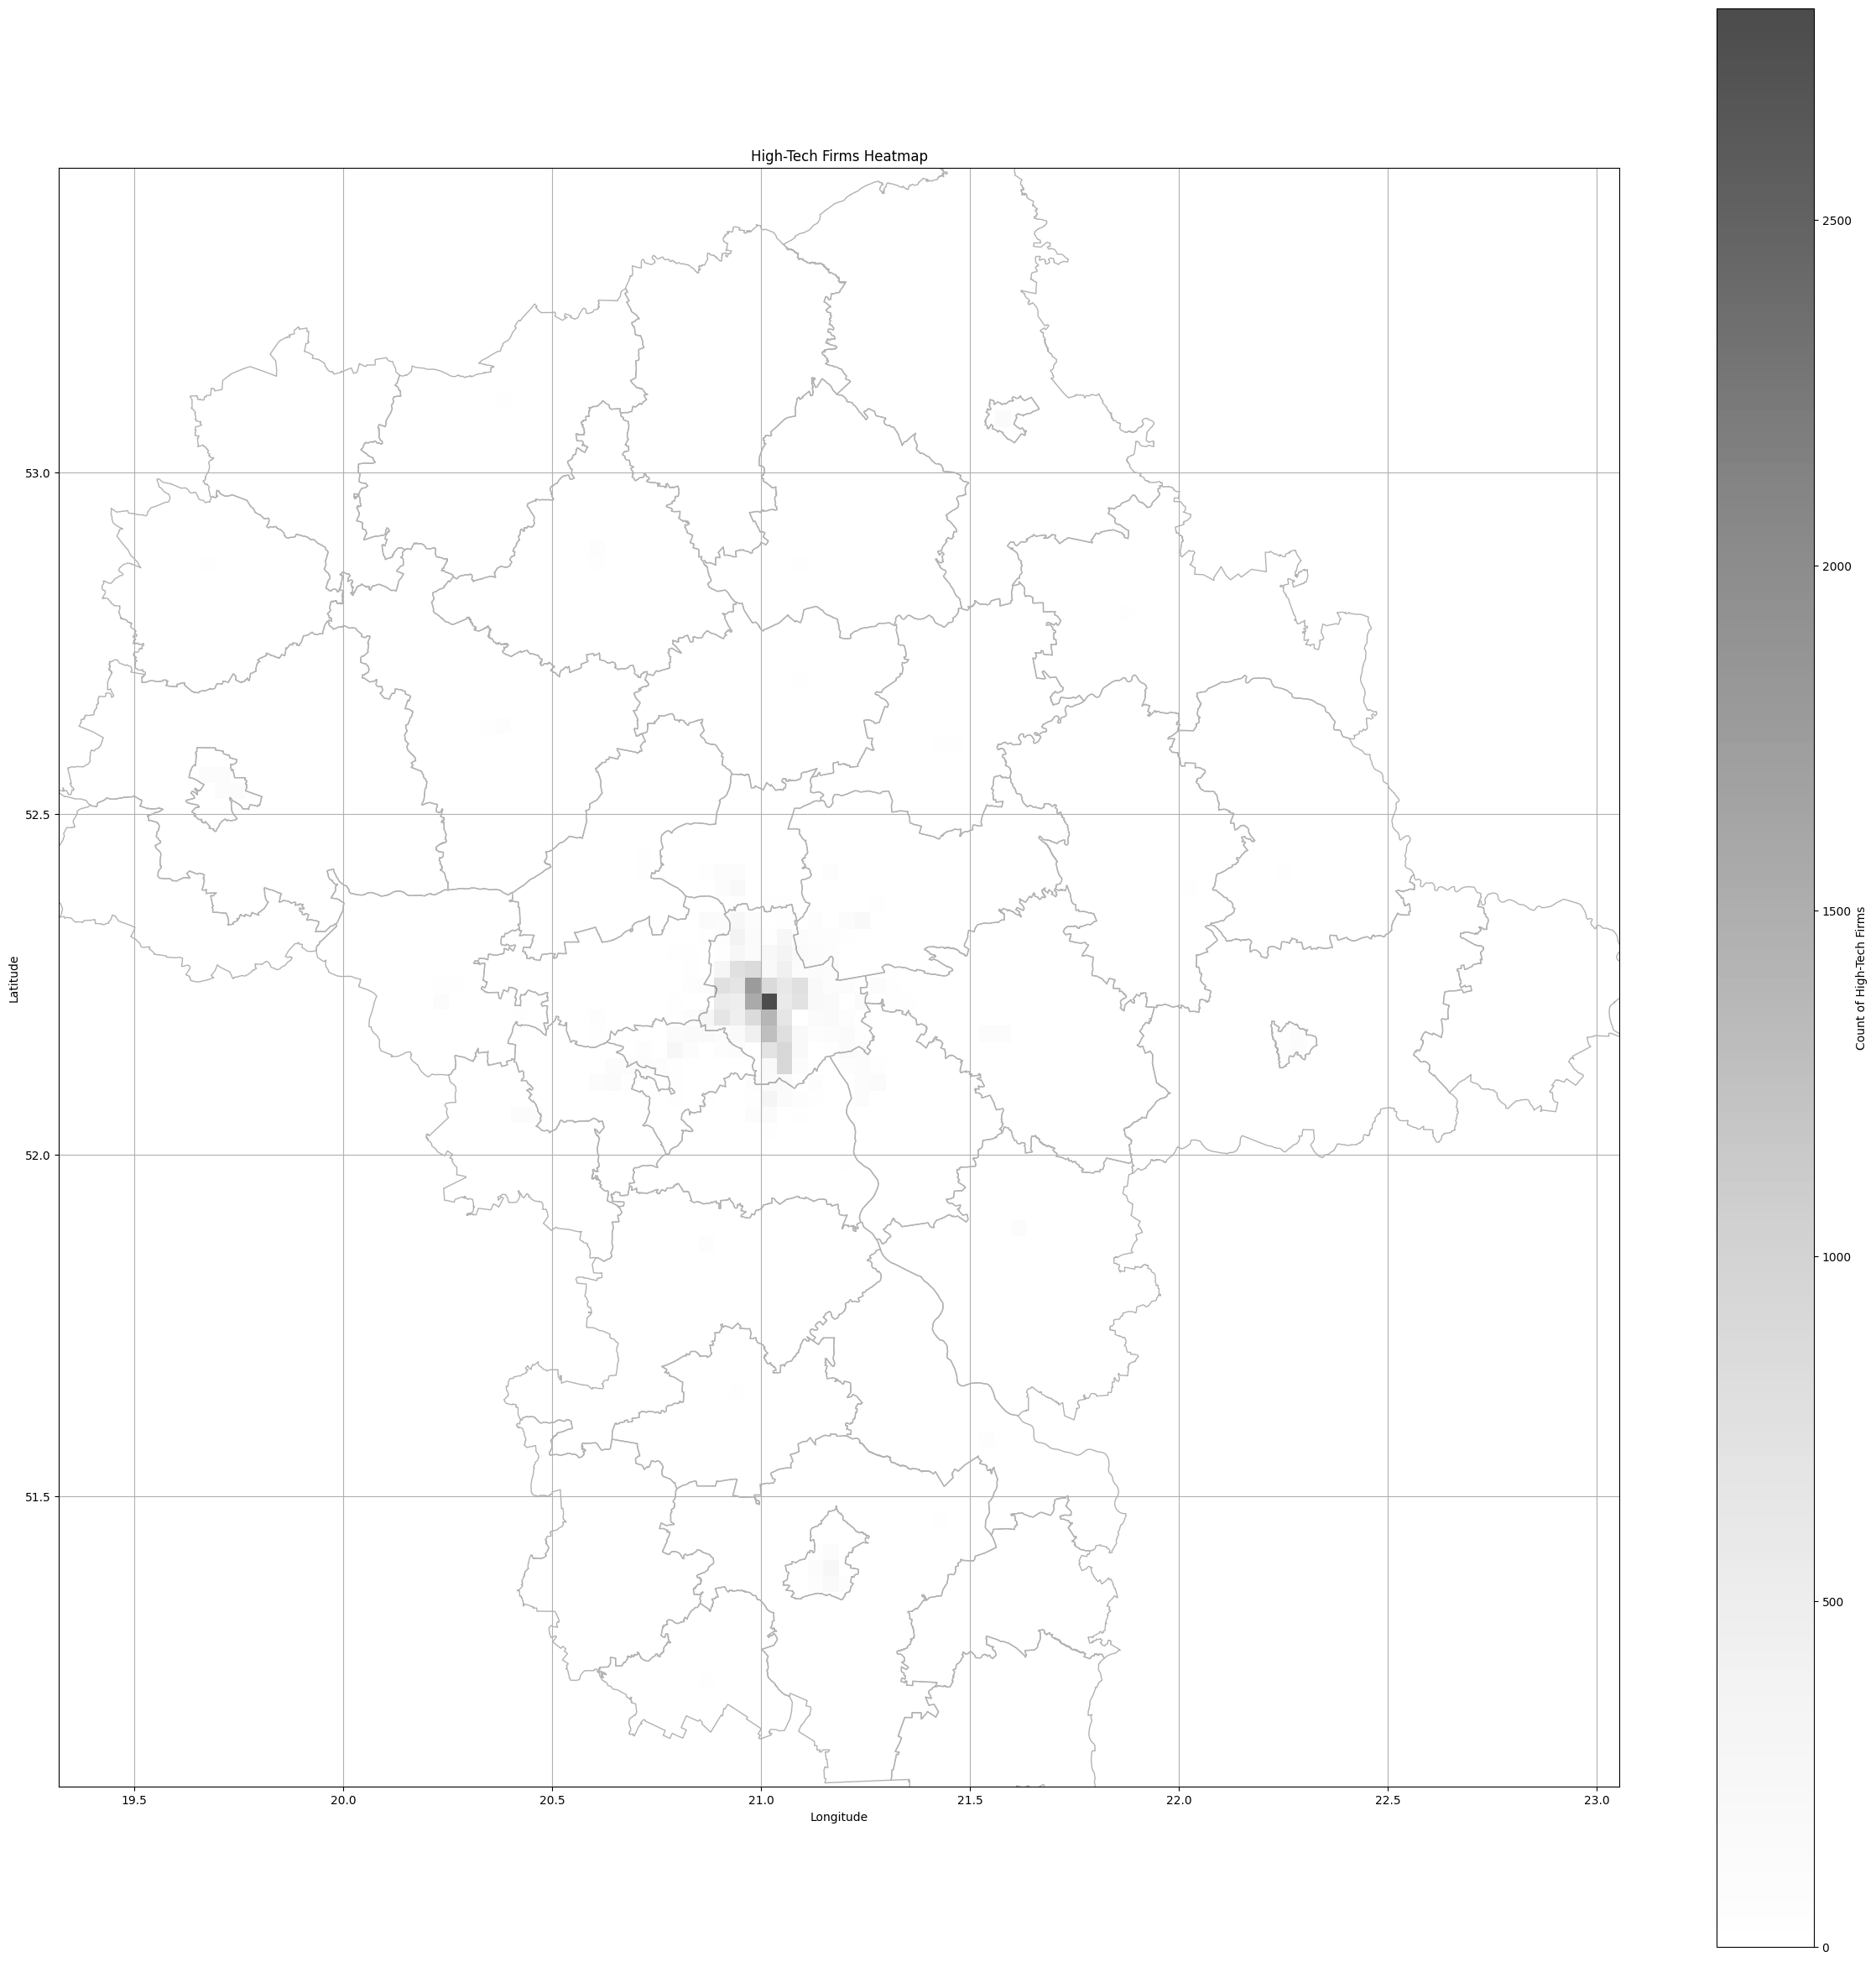

In [37]:
import matplotlib.pyplot as plt
import contextily as ctx

# Create a plot for the borders without the actual map
ax = powiaty_maz.plot(figsize=(30, 30), color='none', edgecolor='black')

# Create histogram with square bins
hb = plt.hist2d(gdf_ht['lon'], gdf_ht['lat'], bins=100, cmap='Greys', alpha=0.7)

# Add color bar
plt.colorbar(hb[3], label='Count of High-Tech Firms')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('High-Tech Firms Heatmap')

plt.grid(True)
plt.show()


(19.13283253, 23.24102607, 50.956313017499994, 53.564640332500005)

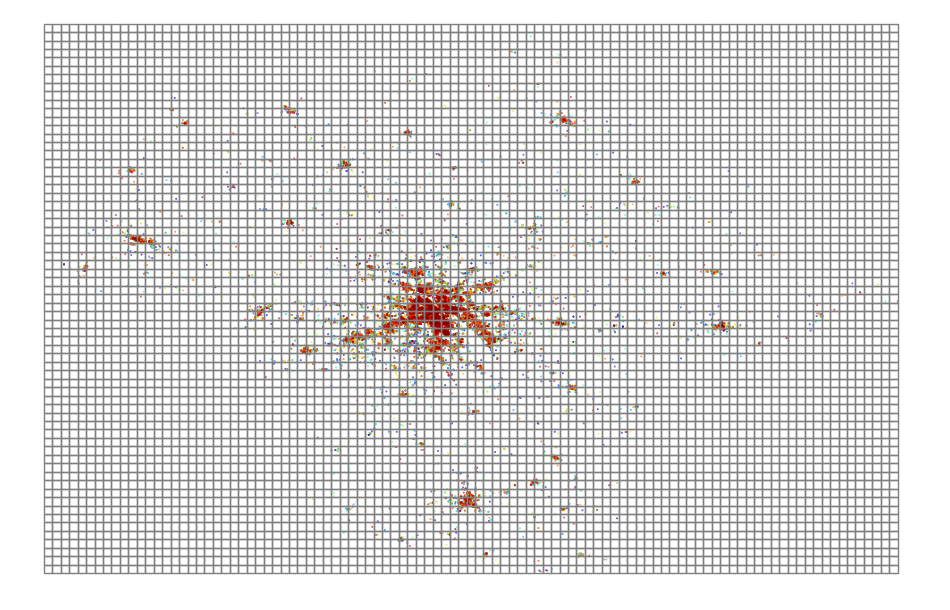

In [30]:
import shapely
# total area for the grid
xmin, ymin, xmax, ymax= gdf_ht.total_bounds
# how many cells across and down
n_cells=100
cell_size = (xmax-xmin)/n_cells
# projection of the grid
crs = "+proj=sinu +lon_0=0 +x_0=0 +y_0=0 +a=6371007.181 +b=6371007.181 +units=m +no_defs"
# create the cells in a loop
grid_cells = []
for x0 in np.arange(xmin, xmax+cell_size, cell_size ):
    for y0 in np.arange(ymin, ymax+cell_size, cell_size):
        # bounds
        x1 = x0-cell_size
        y1 = y0+cell_size
        grid_cells.append(shapely.geometry.box(x0, y0, x1, y1))
cell = gpd.GeoDataFrame(grid_cells, columns=['geometry'], 
                                 crs=crs)

ax = gdf_ht.plot(markersize=.1, figsize=(12, 8), cmap='jet')
plt.autoscale(False)
cell.plot(ax=ax, facecolor="none", edgecolor='grey')
ax.axis("off")

In [45]:
vars_list = ['COREfirms',   'COREpopul',   'dist_core_10',   'dist_core_25',	'dist_core_50',	'dist_midsize_10',	'dist_midsize_25',	'dist_midsize_50',
             'dist_regional_10',	'dist_regional_25',	'dist_regional_50',	'dist_localbig_10',	'dist_localbig_25',	'dist_localbig_50',
             'dist_localsmall_10','dist_localsmall_25', 'dist_localsmall_50']


for var in vars_list:

    cross_tab = pd.crosstab(df['if_hightech'], df[var])
    non_other_obs = cross_tab.index != 'other'
    matching_obs = cross_tab[1][non_other_obs].sum()
    total_non_other_obs = cross_tab[1][non_other_obs].sum() + cross_tab[0][non_other_obs].sum()
    percentage_matching = (matching_obs / total_non_other_obs) * 100

    print(f"For variable '{var}', percentage of high-tech observations from 'techSPEC' that are inside the radius of '{var}': {percentage_matching:.2f}%")
    print(cross_tab)
    print("-" * 50)

For variable 'COREfirms', percentage of high-tech observations from 'techSPEC' that are inside the radius of 'COREfirms': 69.22%
COREfirms         0       1
if_hightech                
0            300455  640923
1              2379   39962
--------------------------------------------------
For variable 'COREpopul', percentage of high-tech observations from 'techSPEC' that are inside the radius of 'COREpopul': 75.17%
COREpopul         0       1
if_hightech                
0            242915  698463
1              1333   41008
--------------------------------------------------
For variable 'dist_core_10', percentage of high-tech observations from 'techSPEC' that are inside the radius of 'dist_core_10': 33.40%
dist_core_10       0       1
if_hightech                 
0             636719  304659
1              18402   23939
--------------------------------------------------
For variable 'dist_core_25', percentage of high-tech observations from 'techSPEC' that are inside the radius of 'd

In [16]:
vars_list = ['COREfirms', 'COREpopul', 'dist_core_10', 'dist_core_25', 'dist_core_50', 'dist_midsize_10', 'dist_midsize_25', 'dist_midsize_50',
             'dist_regional_10', 'dist_regional_25', 'dist_regional_50', 'dist_localbig_10', 'dist_localbig_25', 'dist_localbig_50',
             'dist_localsmall_10', 'dist_localsmall_25', 'dist_localsmall_50']

results = []

for var in vars_list:
    cross_tab = pd.crosstab(df_copy['techSPEC'], df[var])
    non_other_obs = cross_tab.index != 'other'
    matching_obs = cross_tab[1][non_other_obs].sum()
    total_non_other_obs = cross_tab[1][non_other_obs].sum() + cross_tab[0][non_other_obs].sum()
    percentage_hightech = (matching_obs / total_non_other_obs) * 100
    percentage_all = (matching_obs / df.shape[0]) * 100


    result_dict = {
        'Variable': var,
        'Percentage hhightech': f"{percentage_hightech:.2f}%",
        'Percentage All': f"{percentage_all:.2f}%",
        'High-tech (0)': cross_tab.iloc[0,0],
        'High-tech (1)': cross_tab.iloc[0,1],
        'High-tech know-intens (0)': cross_tab.iloc[1,0],
        'High-tech know-intens (1)': cross_tab.iloc[1,1],
        'Medium high-tech (0)': cross_tab.iloc[2,0],
        'Medium high-tech (1)': cross_tab.iloc[2,1],
        'Non-high/medium-tech (0)': cross_tab.iloc[3,0],
        'Non-high/medium-tech (1)': cross_tab.iloc[3,1]

    }
    display(cross_tab)

    results.append(result_dict)

# Creating a DataFrame from the results list
results_tech_df = pd.DataFrame(results)

display(results_tech_df)
# display(cross_tab)
# results_df.to_excel("crosstab.xlsx")

COREfirms,0,1
techSPEC,,
high-tech,107,2066
high-tech know-intens serv,1612,32709
medium-high-tech,660,5187
other,300455,640923


COREpopul,0,1
techSPEC,,
high-tech,48,2125
high-tech know-intens serv,889,33432
medium-high-tech,396,5451
other,242915,698463


dist_core_10,0,1
techSPEC,,
high-tech,980,1193
high-tech know-intens serv,13883,20438
medium-high-tech,3539,2308
other,636719,304659


dist_core_25,0,1
techSPEC,,
high-tech,301,1872
high-tech know-intens serv,4514,29807
medium-high-tech,1786,4061
other,457343,484035


dist_core_50,0,1
techSPEC,,
high-tech,174,1999
high-tech know-intens serv,2655,31666
medium-high-tech,1221,4626
other,345968,595410


...

dist_localbig_50,0,1
techSPEC,,
high-tech,97,2076
high-tech know-intens serv,1388,32933
medium-high-tech,643,5204
other,178933,762445


dist_localsmall_10,0,1
techSPEC,,
high-tech,480,1693
high-tech know-intens serv,7068,27253
medium-high-tech,1886,3961
other,439298,502080


dist_localsmall_25,0,1
techSPEC,,
high-tech,57,2116
high-tech know-intens serv,1185,33136
medium-high-tech,504,5343
other,156567,784811


dist_localsmall_50,0,1
techSPEC,,
high-tech,1,2172
high-tech know-intens serv,29,34292
medium-high-tech,12,5835
other,10550,930828


,Variable,Percentage hhightech,Percentage All,High-tech (0),High-tech (1),High-tech know-intens (0),High-tech know-intens (1),Medium high-tech (0),Medium high-tech (1),Non-high/medium-tech (0),Non-high/medium-tech (1)
0,COREfirms,94.38%,4.06%,107,2066,1612,32709,660,5187,300455,640923
1,COREpopul,96.85%,4.17%,48,2125,889,33432,396,5451,242915,698463
2,dist_core_10,56.54%,2.43%,980,1193,13883,20438,3539,2308,636719,304659
3,dist_core_25,84.41%,3.63%,301,1872,4514,29807,1786,4061,457343,484035
4,dist_core_50,90.43%,3.89%,174,1999,2655,31666,1221,4626,345968,595410
5,dist_midsize_10,1.72%,0.07%,2145,28,33825,496,5641,206,911483,29895
6,dist_midsize_25,3.60%,0.16%,2107,66,33304,1017,5405,442,859260,82118
7,dist_midsize_50,5.04%,0.22%,2082,91,32944,1377,5179,668,787247,154131
8,dist_regional_10,7.88%,0.34%,1985,188,31776,2545,5244,603,867489,73889
9,dist_regional_25,72.07%,3.10%,586,1587,9100,25221,2138,3709,451294,490084


In [31]:
clustering_high_tech = df_copy[df_copy['techSPEC'] != 'other'][['lon', 'lat']]

geometry = [Point(xy) for xy in zip(clustering_high_tech['lon'], clustering_high_tech['lat'])]
gdf = gpd.GeoDataFrame(clustering_high_tech, geometry=geometry, crs="EPSG:4326")

# Perform DBSCAN clustering
eps = 0.05  # Maximum distance between points to consider them in the same neighborhood
min_samples = 30  # Minimum number of points in a neighborhood to consider it a core point
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
gdf['cluster'] = dbscan.fit_predict(clustering_high_tech)

# Create subplots
fig, ax = plt.subplots(figsize=(10, 10))

# Plot clusters
gdf.plot(column='cluster', categorical=True, legend=True, markersize=3, ax=ax, cmap='tab20', missing_kwds={'color': 'grey'})

# Display the plot
plt.show()


KeyboardInterrupt: 

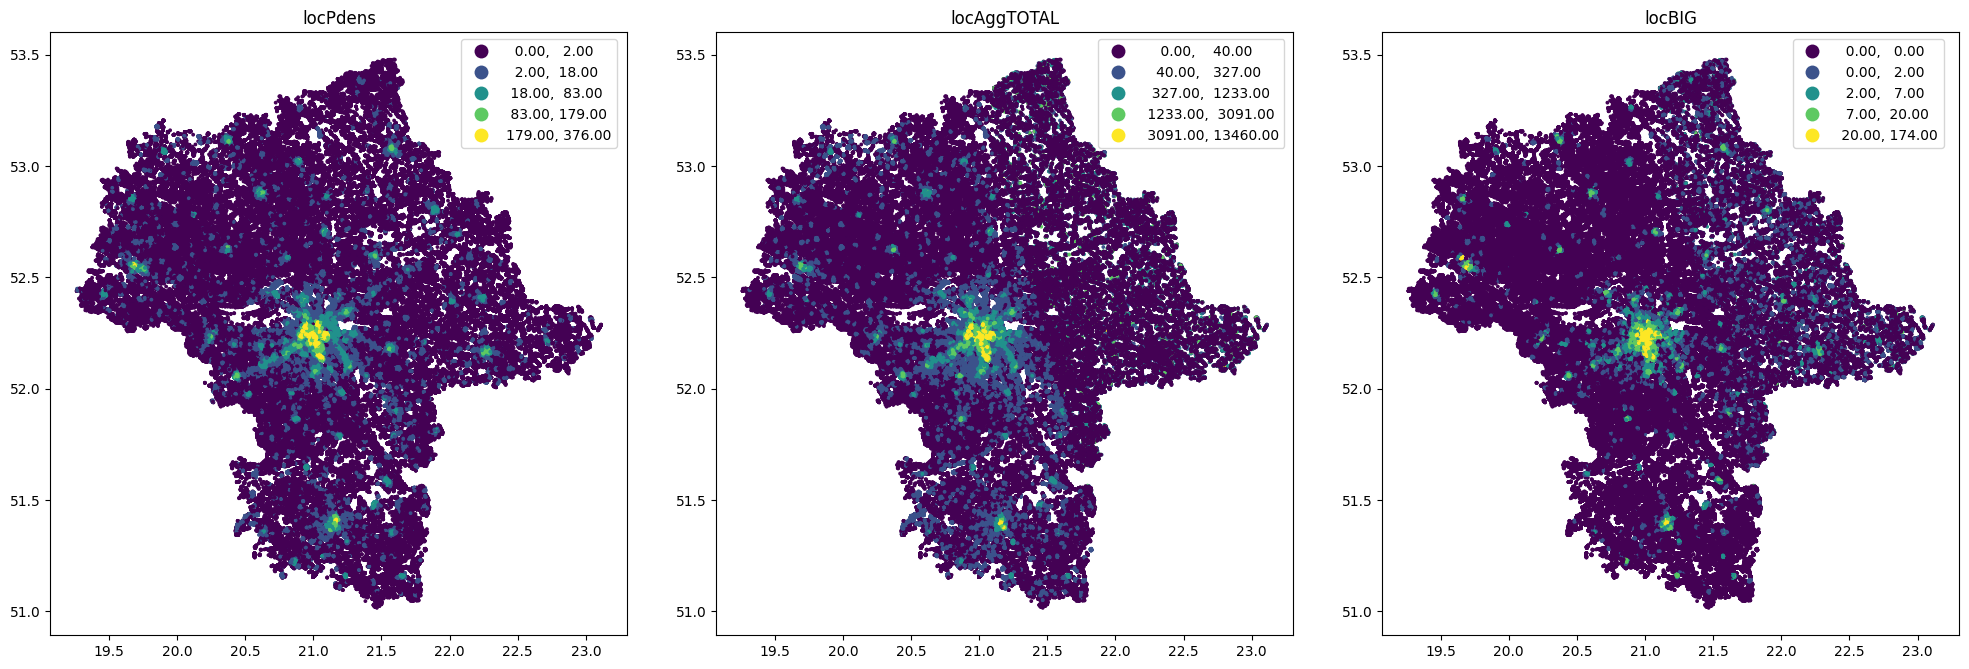

In [18]:
geometry = [Point(xy) for xy in zip(df['lon'], df['lat'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")


fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 10))

gdf.plot(column='locPdens', scheme='quantiles', ax=axes[0], legend=True, markersize=3, legend_kwds={'bbox_to_anchor': (0.7, 1)})
axes[0].set_title('locPdens')

gdf.plot(column='locAggTOTAL', scheme='quantiles', ax=axes[1], legend=True, markersize=3, legend_kwds={'bbox_to_anchor': (0.65, 1)})
axes[1].set_title('locAggTOTAL')

gdf.plot(column='locBIG', scheme='quantiles', ax=axes[2], legend=True, markersize=3, legend_kwds={'bbox_to_anchor': (0.7, 1)})
axes[2].set_title('locBIG')

plt.tight_layout()
plt.show()

In [ ]:
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

geometry = [Point(xy) for xy in zip(df['lon'], df['lat'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# center_point = Point(21.0067, 52.2370)

# # Create a buffer of 10, 25, and 50 kilometers around the center point
# buffer_10km = center_point.buffer(0.1)  # 0.1 degrees approx. 10 km at the equator
# buffer_25km = center_point.buffer(0.25)  # 0.25 degrees approx. 25 km at the equator
# buffer_50km = center_point.buffer(0.5)  # 0.5 degrees approx. 50 km at the equator

# Plot the GeoDataFrame and circles
fig, ax = plt.subplots(figsize=(10, 5))
gdf.plot(column='techSPEC', ax=ax, legend=True, markersize=2, legend_kwds={'bbox_to_anchor': (0.64, 0.82)})

# Plot circles around the center point
# gpd.GeoSeries(buffer_10km).plot(ax=ax, color='none', edgecolor='black', linewidth=2)
# gpd.GeoSeries(buffer_25km).plot(ax=ax, color='none', edgecolor='black', linewidth=2)
# gpd.GeoSeries(buffer_50km).plot(ax=ax, color='none', edgecolor='black', linewidth=2)

plt.tight_layout()
plt.show()


In [ ]:
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

# Your DataFrame df and its 'lon' and 'lat' columns should be defined here

geometry = [Point(xy) for xy in zip(df['lon'], df['lat'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# Define the center point
center_point = Point(21.0067, 52.2370)

# Convert the buffer sizes to the plot's coordinate system (assuming it's in meters)
buffer_size_meters = [10000, 25000, 50000]  # 10 km, 25 km, 50 km

# Create buffers using the buffer sizes in meters
buffers = [center_point.buffer(buffer_size / (40008000 / 360)) for buffer_size in buffer_size_meters]

# Convert the buffers to the same coordinate system as gdf
buffers = gpd.GeoSeries(buffers, crs="EPSG:4326")
buffers = buffers.to_crs(gdf.crs)

# Plot the GeoDataFrame and circles
fig, ax = plt.subplots(figsize=(10, 5))
gdf.plot(column='techSPEC', ax=ax, legend=True, markersize=2, legend_kwds={'bbox_to_anchor': (0.64, 0.82)})

# Plot circles around the center point
buffers.plot(ax=ax, color='none', edgecolor='black', linewidth=2)

plt.tight_layout()
plt.show()


In [ ]:
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

# Assuming gdf is your GeoDataFrame
center_lon, center_lat = 21.0067, 52.2370  # Center of Warsaw
center_point = Point(center_lon, center_lat)

# Calculate accurate distances using geodesic distance
buffer_10km = center_point.buffer(0.1)  # 0.1 degrees approx. 10 km at the equator
buffer_25km = center_point.buffer(0.25)  # 0.25 degrees approx. 25 km at the equator
buffer_50km = center_point.buffer(0.5)


# Assuming you have calculated percentage_matching for each radius
percentage_matching_10km = 56.54  # Replace with actual calculated percentage
percentage_matching_25km = 84.41  # Replace with actual calculated percentage
percentage_matching_50km = 90.43  # Replace with actual calculated percentage

# Create GeoSeries for the circles
circle_10km = gpd.GeoSeries(buffer_10km)
circle_25km = gpd.GeoSeries(buffer_25km)
circle_50km = gpd.GeoSeries(buffer_50km)

# Plot the GeoDataFrame and circles
fig, ax = plt.subplots(figsize=(20,6))
gdf.plot(column='techSPEC', ax=ax, legend=True, markersize=2, legend_kwds={'bbox_to_anchor': (1, 1)})

# Plot circles around the center point with more visible lines
circle_10km.plot(ax=ax, color='none', edgecolor='blue', linewidth=2, linestyle='solid')
circle_25km.plot(ax=ax, color='none', edgecolor='yellow', linewidth=2, linestyle='solid')
circle_50km.plot(ax=ax, color='none', edgecolor='red', linewidth=2, linestyle='solid')

# Create legend handles for the circles
legend_handles = [
    Patch(color='blue', edgecolor='blue', linewidth=2, linestyle='solid', label=f'10km:{percentage_matching_10km:.2f}%'),
    Patch(color='yellow', edgecolor='yellow', linewidth=2, linestyle='solid', label=f'25km:{percentage_matching_25km:.2f}%'),
    Patch(color='red', edgecolor='red', linewidth=2, linestyle='solid', label=f'50km:{percentage_matching_50km:.2f}%')
]

# Add legend with custom handles
ax.legend(handles=legend_handles)

plt.show()


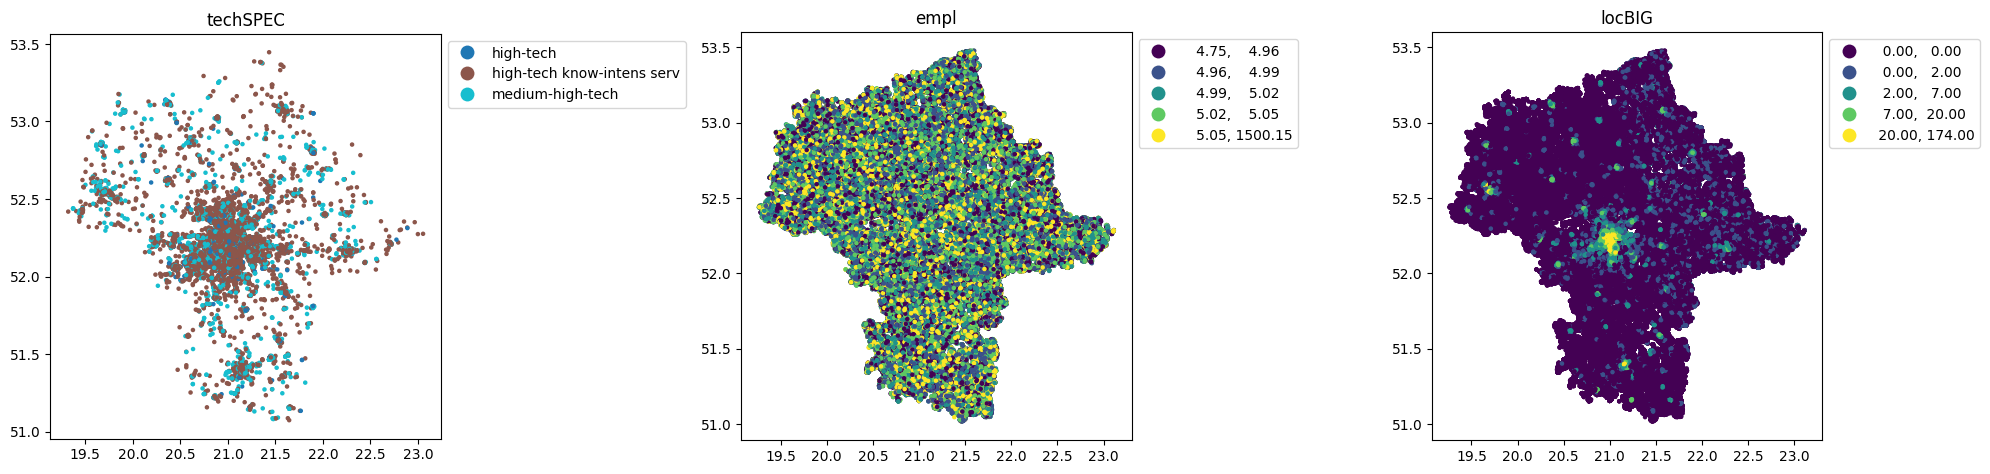

In [19]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 10))


gdf.plot(column='techSPEC', ax=axes[0], legend=True, markersize=5, legend_kwds={'bbox_to_anchor': (1, 1)})
axes[0].set_title('techSPEC')

gdf.plot(column='empl', scheme='quantiles', ax=axes[1], legend=True, markersize=5, legend_kwds={'bbox_to_anchor': (1, 1)})
axes[1].set_title('empl')

gdf.plot(column='locBIG', scheme='quantiles', ax=axes[2], legend=True, markersize=5, legend_kwds={'bbox_to_anchor': (1, 1)})
axes[2].set_title('locBIG')

plt.tight_layout()
plt.show()